In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('Housing.csv')

# Display basic info to check column names (e.g., 'Price', 'Area', 'Bedrooms')
print(df.head())
print("\nChecking for null values:\n", df.isnull().sum())

# Drop any missing values for a clean regression
df = df.dropna()

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Checking for null values:
 price               0
area                0
bedrooms            0
bathr

In [5]:
# Define Features (X) and Target (y) using lowercase column names
X = df[['area', 'bedrooms', 'bathrooms']] 
y = df['price']

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (436, 3)
Testing data shape: (109, 3)


In [6]:
# Initialize the model using scikit-learn
model = LinearRegression()

# Train (fit) the model using the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

print("Model successfully trained and predictions generated!")

Model successfully trained and predictions generated!


In [7]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): 1265275.67
Mean Squared Error (MSE): 2750040479309.05
R-squared Score: 0.4559


--- Model Coefficients ---
Intercept: 59485.38
- area: 345.47
- bedrooms: 360197.65
- bathrooms: 1422319.66


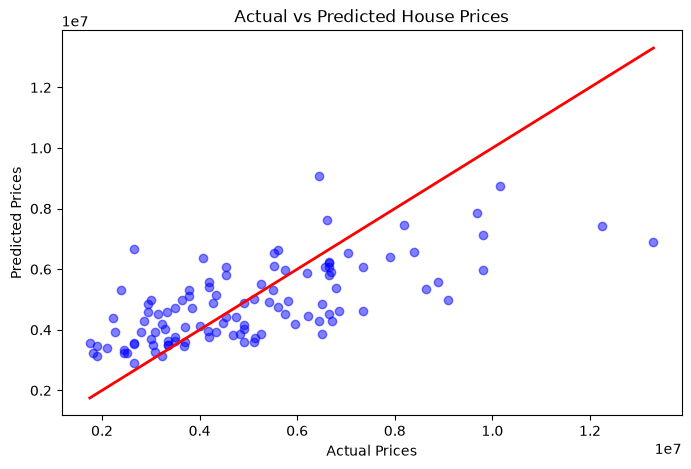

In [8]:
# Print the coefficients and intercept
print("--- Model Coefficients ---")
print(f"Intercept: {model.intercept_:.2f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"- {feature}: {coef:.2f}")

# Plotting Actual vs Predicted Prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()